* Operations:
  1. Create a handle
  2. Open device
  3. Set parameters
  4. Start image grabbing
  5. Stop grabbing
  6. Close device
  7. Destroy the handle

In [1]:
%matplotlib inline 
import ctypes, numpy as np, time, sys, matplotlib.pyplot as plt
from PIL import Image
from datetime import datetime
sys.path.append("/opt/MVS/Samples/64/Python/MvImport")
import MvCameraControl_class as MvCC # import relevant functions

class MVS_Error(Exception):
    def __init__(self, key):
        # please refer to SDK Internal-Defined Status Codes in the SDK Manual
        Error_Codes = {
            MvCC.MV_E_GC_RANGE:'The value is out of range.',
            MvCC.MV_E_GC_ACCESS:'Incorrect node access condition'
        }   
        self.value = Error_Codes[key]
 
    def __str__(self):
        return(repr(self.value))

class GIGE: 
    def _setEnum_(self, name, value, debug=False):
        value = int(value)
        ret = self.cam.MV_CC_SetEnumValue(name, value)
        if ret == 0:
            return
        elif not debug:
            raise MVS_Error(ret)
        else:
            print(name, hex(ret))
            return ret
        
    def _setFloat_(self, name, value, debug=False):
        value = float(value)
        ret = self.cam.MV_CC_SetFloatValue(name, value)
        if ret == 0:
            return
        elif not debug:
            raise MVS_Error(ret)
        else:
            print(name, hex(ret))
            return ret 
        
    def _setInt_(self, name, value, debug=False):
        value = int(value)
        ret = self.cam.MV_CC_SetIntValue(name, value)
        if ret == 0:
            return
        elif not debug:
            raise MVS_Error(ret)
        else:
            print(name, hex(ret))
            return ret 

    def _getEnum_(self, name, debug=False):
        stEnumValue =  MvCC.MVCC_ENUMVALUE()
        ctypes.memset(ctypes.byref(stEnumValue), 0, ctypes.sizeof(MvCC.MVCC_ENUMVALUE))
        ret = self.cam.MV_CC_GetEnumValue(name, stEnumValue)
        if ret == 0:
            return stEnumValue.nCurValue
        elif not debug:
            raise MVS_Error(ret)
        else:
            print(name, hex(ret))
            return ret  

    def _getFloat_(self, name, debug=False):
        stFloatValue = MvCC.MVCC_FLOATVALUE()
        ctypes.memset(ctypes.byref(stFloatValue), 0, ctypes.sizeof(MvCC.MVCC_FLOATVALUE))
        ret = self.cam.MV_CC_GetFloatValue(name, stFloatValue)
        if ret == 0:
            return stFloatValue.fCurValue
        elif not debug:
            raise MVS_Error(ret)
        else:
            print(name, hex(ret))
            return ret   

    def _getInt_(self, name, debug=False):
        stIntValue =  MvCC.MVCC_INTVALUE()
        ctypes.memset(ctypes.byref(stIntValue), 0, ctypes.sizeof(MvCC.MVCC_INTVALUE))
        ret = self.cam.MV_CC_GetIntValue(name, stIntValue)  
        if ret == 0:
            return stIntValue.nCurValue
        elif not debug:
            raise MVS_Error(ret)
        else:
            print(name, hex(ret))
            return ret  

    def __init__(self, ExposureTime=168724.0):
        # Enumerate Devices
        pstDevList  = MvCC.MV_CC_DEVICE_INFO_LIST() # Create a device list 
        ret = MvCC.MvCamera.MV_CC_EnumDevices(MvCC.MV_GIGE_DEVICE, pstDevList)
        if ret != 0 or pstDevList.nDeviceNum == 0:
            print('No Gige camera is available')
            raise

        # Initialize Camera
        cam = MvCC.MvCamera()

        # 1. Create Handle
        nDeviceIndex = 0 # We choose the first camera
        stDevInfo = ctypes.cast(pstDevList.pDeviceInfo[nDeviceIndex], ctypes.POINTER(MvCC.MV_CC_DEVICE_INFO)).contents
        ret = cam.MV_CC_CreateHandle(stDevInfo)
        if ret != 0: 
            print ("create handle fail! ret[0x%x]" % ret)
            raise

        # 2. Open Device
        ret = cam.MV_CC_OpenDevice(MvCC.MV_ACCESS_Exclusive, 0)
        if ret != 0:
            print ("open device fail! ret[0x%x]" % ret)
            raise

        # 3. Set Parameter
        cam.MV_CC_SetEnumValue ("TriggerMode" , MvCC.MV_TRIGGER_MODE_OFF       )
        cam.MV_CC_SetEnumValue ('PixelFormat' , MvCC.PixelType_Gvsp_RGB8_Packed)  
        cam.MV_CC_SetEnumValue ('ExposureAuto', MvCC.MV_EXPOSURE_AUTO_MODE_OFF ) 
        cam.MV_CC_SetFloatValue('ExposureTime', ExposureTime                   ) 
        
        self.cam       = cam
        self.widthMax  = self._getInt_("WidthMax")
        self.heightMax = self._getInt_("HeightMax") 
        print('Camera is ready ~')
        
        # Make nonsense
        assert MvCC.MV_E_GC_ACCESS == cam.MV_CC_SetEnumValue ('ImageCompressionMode' , {'Off':0,'JPEG':1}['JPEG']) 

    def getFrame(self, nFrame=100, debug=False):  
        # Creat a Container of image data and information
        stOutFrame = MvCC.MV_FRAME_OUT()
        ctypes.memset(ctypes.byref(stOutFrame), 0, ctypes.sizeof(stOutFrame))
        
        # 4. Start Grabbing
        ret = self.cam.MV_CC_StartGrabbing()
        if ret != 0:
            print("start grabbing fail! ret[0x%x]" % ret)
            raise 

        # Fill the container
        ret = self.cam.MV_CC_GetImageBuffer(stFrame=stOutFrame, nMsec=10000) # nMsec: Timeout duration in millisecond
        if 0 != ret or None == stOutFrame.pBufAddr:
            print("No Image is captured[0x%x]" % ret) 
            raise

        if MvCC.PixelType_Gvsp_RGB8_Packed != stOutFrame.stFrameInfo.enPixelType:
            print("PixelType is Not Supported");
            raise

        # Have some fun
        assert stOutFrame.stFrameInfo.nFrameLen == stOutFrame.stFrameInfo.nWidth * stOutFrame.stFrameInfo.nHeight * 3

        # Allocate image buffer 
        im_buf = (ctypes.c_ubyte * stOutFrame.stFrameInfo.nFrameLen)()

        # Empty the image data but 
        self.cam.MV_CC_FreeImageBuffer(stOutFrame)

        begin = time.time()
        for i in range(nFrame):
            ret = self.cam.MV_CC_GetImageBuffer(stFrame=stOutFrame, nMsec=10000) # nMsec: Timeout duration in millisecond
            if 0 != ret or None == stOutFrame.pBufAddr:
                print("No Image is captured[0x%x]" % ret)
                raise
            if debug: print(f"nFrameNum: {stOutFrame.stFrameInfo.nFrameNum} @ {datetime.now().strftime('%Y-%m-%dT%H:%M:%S.%f')}")
            ctypes.memmove(ctypes.byref(im_buf), stOutFrame.pBufAddr, stOutFrame.stFrameInfo.nFrameLen) # 图像数据拷贝并不太耗资源
            im = Image.frombytes(mode="RGB", data=im_buf, decoder_name="raw", 
                                 size=(stOutFrame.stFrameInfo.nWidth, stOutFrame.stFrameInfo.nHeight)) 
            self.cam.MV_CC_FreeImageBuffer(stOutFrame)
        end = time.time()
        print('FPS :', nFrame/(end-begin))

        # 5. Stop Grabbing
        ret = self.cam.MV_CC_StopGrabbing()
        if ret != 0:
            print ("stop grabbing fail! ret[0x%x]" % ret)
            raise

        plt.imshow(im)
        plt.show()
        return stOutFrame

    def close(self):
        # 6. Close Device
        ret = self.cam.MV_CC_CloseDevice()
        if ret != 0:
            print ("close deivce fail! ret[0x%x]" % ret)
            raise

        # 7. Destroy Handle
        ret = self.cam.MV_CC_DestroyHandle()
        if ret != 0:
            print ("destroy handle fail! ret[0x%x]" % ret)

        MvCC.MvCamera.MV_CC_Finalize() 
        return
        
    def setROI(self, x=1000, y=1000, w=1000, h=1000, debug=False):  
        plt.xlim(-100, w + 100)
        plt.ylim(-100, h + 100)
        plt.close()
        self._setInt_('OffsetX', x, debug=debug)
        self._setInt_('OffsetY', y, debug=debug)  
        self._setInt_('Width'  , w, debug=debug) 
        self._setInt_('Height' , h, debug=debug)   
        return
        
    def resetROI(self): 
        self._setInt_('OffsetX', 0)
        self._setInt_('OffsetY', 0)  
        self._setInt_('Width'  , self.widthMax ) 
        self._setInt_('Height' , self.heightMax)   
        return
        
gige = GIGE(ExposureTime=40_000.0)

Camera is ready ~


In [2]:
gige.setROI(x=2752, y=556, w=1688, h=1638, debug=False)  

FPS : 5.926285963124048


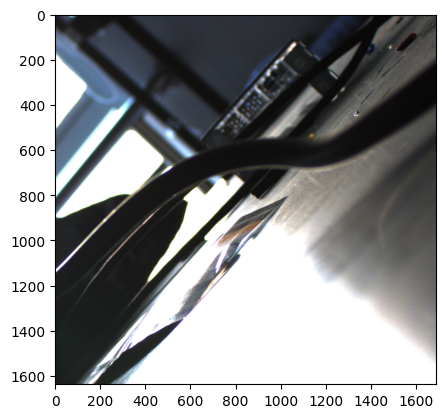

(1688, 1638)

In [3]:
stOutFrame = gige.getFrame(nFrame=10, debug=False) 
stOutFrame.stFrameInfo.nWidth, stOutFrame.stFrameInfo.nHeight

In [4]:
gige.close()

In [5]:
_ = '''
im = cv.cvtColor(im, cv.COLOR_RGB2BGR) 
im = np.frombuffer(im_buf, count=stOutFrame.stFrameInfo.nFrameLen, dtype=np.uint8)
im = im.reshape((stOutFrame.stFrameInfo.nHeight, stOutFrame.stFrameInfo.nWidth, 3)) 
im = cv.resize(im, (0,0), fx=0.2, fy=0.2) # 20%
im = im[100:200, 100:200, :]
im.save(f"123.jpeg") 
'''